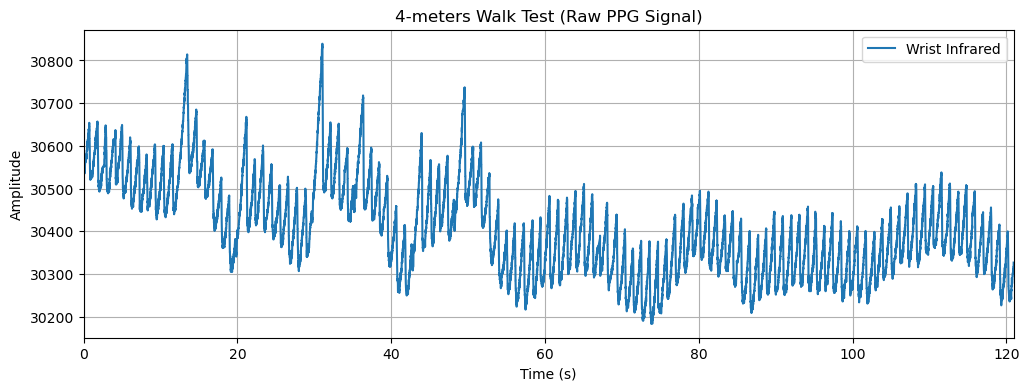

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('base.csv', sep=',')

df['Zeit_s'] = pd.to_timedelta('00:' + df['Timestamp']).dt.total_seconds()

df['Zeit_rel'] = df['Zeit_s'] - df['Zeit_s'].iloc[0]

plt.figure(figsize=(12, 4))
plt.plot(df['Zeit_rel'], df['Ir2'], label='Wrist Infrared')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('4-meters Walk Test (Raw PPG Signal)')
plt.legend()
plt.grid(True)

plt.margins(x=0)
plt.xlim(left=0)

plt.show()


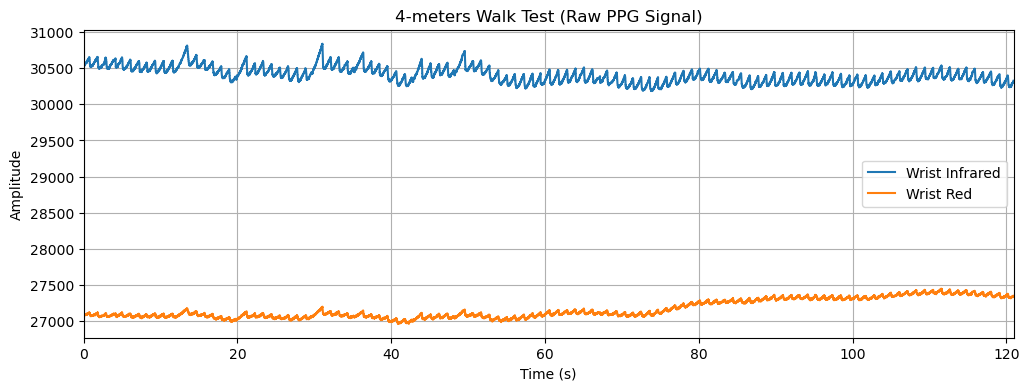

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('base.csv', sep=',')

df['Zeit_s'] = pd.to_timedelta('00:' + df['Timestamp']).dt.total_seconds()

df['Zeit_rel'] = df['Zeit_s'] - df['Zeit_s'].iloc[0]

plt.figure(figsize=(12, 4))
plt.plot(df['Zeit_rel'], df['Ir2'], label='Wrist Infrared')
plt.plot(df['Zeit_rel'], df['Red2'], label='Wrist Red')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('4-meters Walk Test (Raw PPG Signal)')
plt.legend()
plt.grid(True)

plt.margins(x=0)
plt.xlim(left=0)

plt.show()


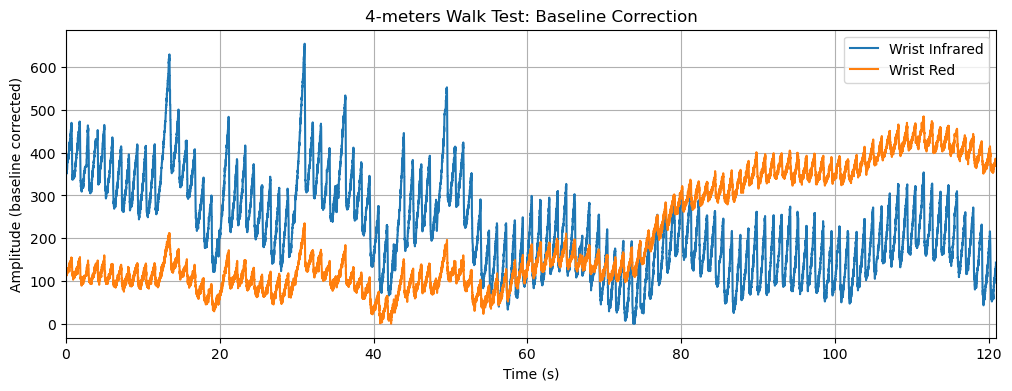

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('base.csv', sep=',')

df['Zeit_s'] = pd.to_timedelta('00:' + df['Timestamp']).dt.total_seconds()

df['Zeit_rel'] = df['Zeit_s'] - df['Zeit_s'].iloc[0]

ir2_baseline = df['Ir2'].min()
red2_baseline = df['Red2'].min()

df['Ir2_adj'] = df['Ir2'] - ir2_baseline
df['Red2_adj'] = df['Red2'] - red2_baseline

plt.figure(figsize=(12, 4))
plt.plot(df['Zeit_rel'], df['Ir2_adj'], label='Wrist Infrared')
plt.plot(df['Zeit_rel'], df['Red2_adj'], label='Wrist Red')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (baseline corrected)')
plt.title('4-meters Walk Test: Baseline Correction')
plt.legend()
plt.grid(True)

plt.margins(x=0)
plt.xlim(left=0)

plt.show()


In [28]:
delta_t = df['Zeit_rel'].iloc[1] - df['Zeit_rel'].iloc[0]
fs = round(1 / delta_t)
print(f"Sampling-Frequency: {fs} Hz")


Sampling-Frequency: 125 Hz


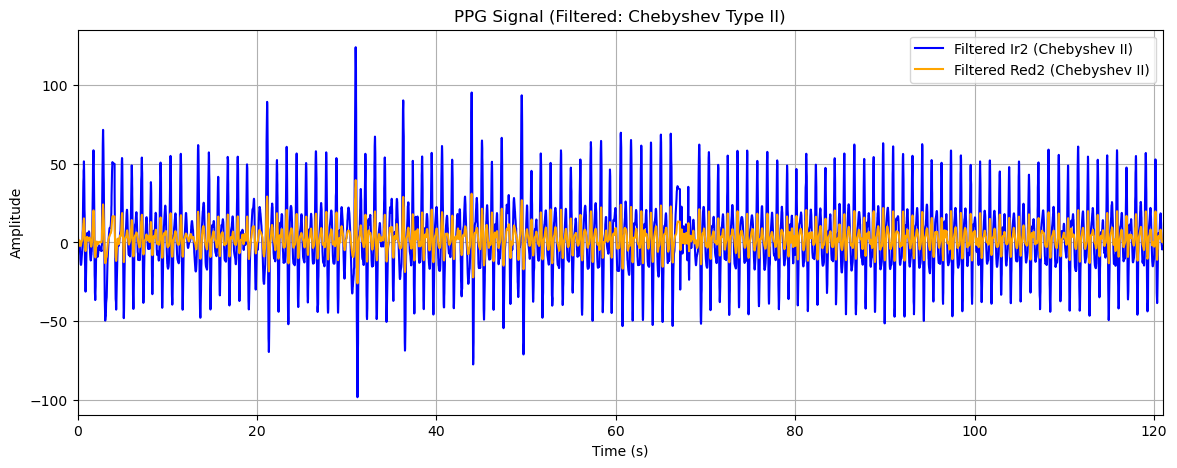

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import cheby2, filtfilt

df = pd.read_csv('base.csv', sep=',')

df['Zeit_s'] = pd.to_timedelta('00:' + df['Timestamp']).dt.total_seconds()
df['Zeit_rel'] = df['Zeit_s'] - df['Zeit_s'].iloc[0]

fs = 125  # Anpassen, falls nötig!

# Chebyshev Type II Bandpass Filter konfigurieren (0.5–5 Hz)
lowcut = 0.5
highcut = 5.0
order = 4
rs = 40  # dB Dämpfung im Sperrbereich

nyq = 0.5 * fs
low = lowcut / nyq
high = highcut / nyq

b, a = cheby2(N=order, rs=rs, Wn=[low, high], btype='bandpass')

df['Ir2_filtered'] = filtfilt(b, a, df['Ir2'])
df['Red2_filtered'] = filtfilt(b, a, df['Red2'])

plt.figure(figsize=(14, 5))
plt.plot(df['Zeit_rel'], df['Ir2_filtered'], label='Filtered Ir2 (Chebyshev II)', color='blue')
plt.plot(df['Zeit_rel'], df['Red2_filtered'], label='Filtered Red2 (Chebyshev II)', color='orange')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('PPG Signal (Filtered: Chebyshev Type II)')
plt.grid(True)
plt.legend()

plt.margins(x=0)
plt.xlim(left=0)

plt.show()


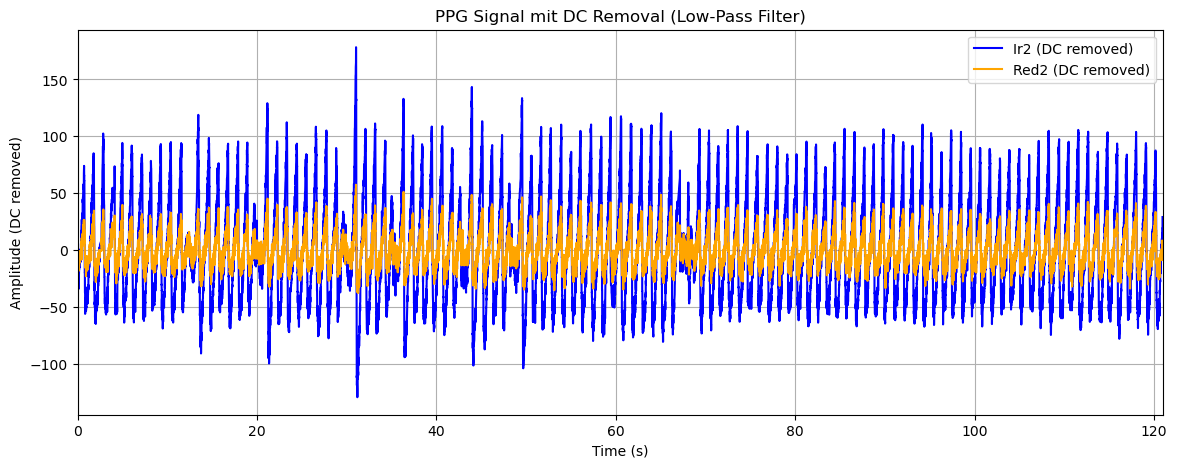

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

df = pd.read_csv('base.csv', sep=',')

df['Zeit_s'] = pd.to_timedelta('00:' + df['Timestamp']).dt.total_seconds()
df['Zeit_rel'] = df['Zeit_s'] - df['Zeit_s'].iloc[0]

fs = 125  # anpassen, falls nötig

cutoff = 0.5  # Hz
order = 4

nyq = 0.5 * fs
normal_cutoff = cutoff / nyq

# Butterworth Tiefpass-Filter
b, a = butter(N=order, Wn=normal_cutoff, btype='low')

df['Ir2_dc'] = filtfilt(b, a, df['Ir2'])
df['Red2_dc'] = filtfilt(b, a, df['Red2'])

df['Ir2_dc_removed'] = df['Ir2'] - df['Ir2_dc']
df['Red2_dc_removed'] = df['Red2'] - df['Red2_dc']

plt.figure(figsize=(14, 5))
plt.plot(df['Zeit_rel'], df['Ir2_dc_removed'], label='Ir2 (DC removed)', color='blue')
plt.plot(df['Zeit_rel'], df['Red2_dc_removed'], label='Red2 (DC removed)', color='orange')

plt.xlabel('Time (s)')
plt.ylabel('Amplitude (DC removed)')
plt.title('PPG Signal mit DC Removal (Low-Pass Filter)')
plt.grid(True)
plt.legend()

plt.margins(x=0)
plt.xlim(left=0)

plt.show()


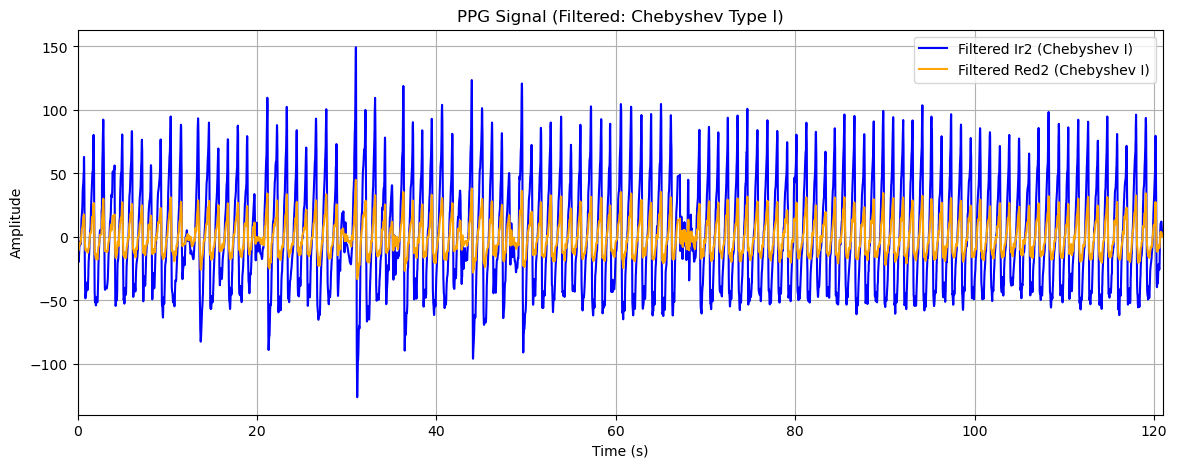

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import cheby1, filtfilt

df = pd.read_csv('base.csv', sep=',')

df['Zeit_s'] = pd.to_timedelta('00:' + df['Timestamp']).dt.total_seconds()
df['Zeit_rel'] = df['Zeit_s'] - df['Zeit_s'].iloc[0]

fs = 125  # anpassen, falls nötig

lowcut = 0.5
highcut = 5.0
order = 4
rp = 1

nyq = 0.5 * fs
low = lowcut / nyq
high = highcut / nyq

# Filterkoeffizienten für Chebyshev Type I
b, a = cheby1(N=order, rp=rp, Wn=[low, high], btype='bandpass')

df['Ir2_filtered'] = filtfilt(b, a, df['Ir2'])
df['Red2_filtered'] = filtfilt(b, a, df['Red2'])

plt.figure(figsize=(14, 5))
plt.plot(df['Zeit_rel'], df['Ir2_filtered'], label='Filtered Ir2 (Chebyshev I)', color='blue')
plt.plot(df['Zeit_rel'], df['Red2_filtered'], label='Filtered Red2 (Chebyshev I)', color='orange')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('PPG Signal (Filtered: Chebyshev Type I)')
plt.grid(True)
plt.legend()

plt.margins(x=0)
plt.xlim(left=0)

plt.show()
